# Distance-Based Localization in PET

**`DistanceLocalization`** builds a sparse localization operator by placing a spatial kernel around each observation's well location. Only state cells within kernel range receive non-zero weights.

This tutorial covers:
1. The three kernel types: `gc` (Gaspari-Cohn), `fb` (Furrer-Bengtsson), `region`
2. Configuring entries (Python dict, CSV file, TOML)
3. `radius`, wildcards, and multiple entries
4. Visualising the tapering matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from misc.structures import PETDataFrame
from pipt.localization import DistanceLocalization

## 1. Build synthetic observed data

To keep this tutorial self-contained, we create synthetic observation data for two wells (`WOPR:W1`, `WOPR:W2`) at a few report times.
These synthetic values are only used to demonstrate localization setup and plotting.

In [2]:
# Two synthetic wells (not at corners) used throughout the tutorial
well1_name, well1_x, well1_y = "WOPR:W1", 14, 14
well2_name, well2_x, well2_y = "WOPR:W2", 34, 34

dates = pd.to_datetime(["2005-01-01", "2005-01-15", "2005-02-01"])
synthetic_df = pd.DataFrame(
    {
        well1_name: [1200.0, 1150.0, 1090.0],
        well2_name: [900.0, 940.0, 980.0],
    },
    index=dates,
)
synthetic_df.index.name = "time"

# Build PETDataFrame
data = PETDataFrame.from_pandas(synthetic_df)

print("Synthetic data:")
print(data)
print('\n')
print(f"Well 1: {well1_name} at ({well1_x}, {well1_y})")
print(f"Well 2: {well2_name} at ({well2_x}, {well2_y})")

Synthetic data:
            WOPR:W1  WOPR:W2
time                        
2005-01-01   1200.0    900.0
2005-01-15   1150.0    940.0
2005-02-01   1090.0    980.0


Well 1: WOPR:W1 at (14, 14)
Well 2: WOPR:W2 at (34, 34)


## 2. Kernel types

| Kernel | Tag | Profile | Compact support |
|--------|-----|---------|-----------------|
| Gaspari-Cohn | `gc` | Smooth polynomial | `2 × radius` cells |
| Furrer-Bengtsson | `fb` | Ensemble-size aware | `radius` cells |
| Region | `region` | Binary (0/1) | 1 cell (point mask) |

For this comparison, Well 1 is at `(14, 14)` on a 50×50×1 grid.
In all spatial maps below, the red `x` marks the observation (measurement) location used to center the localization kernel.

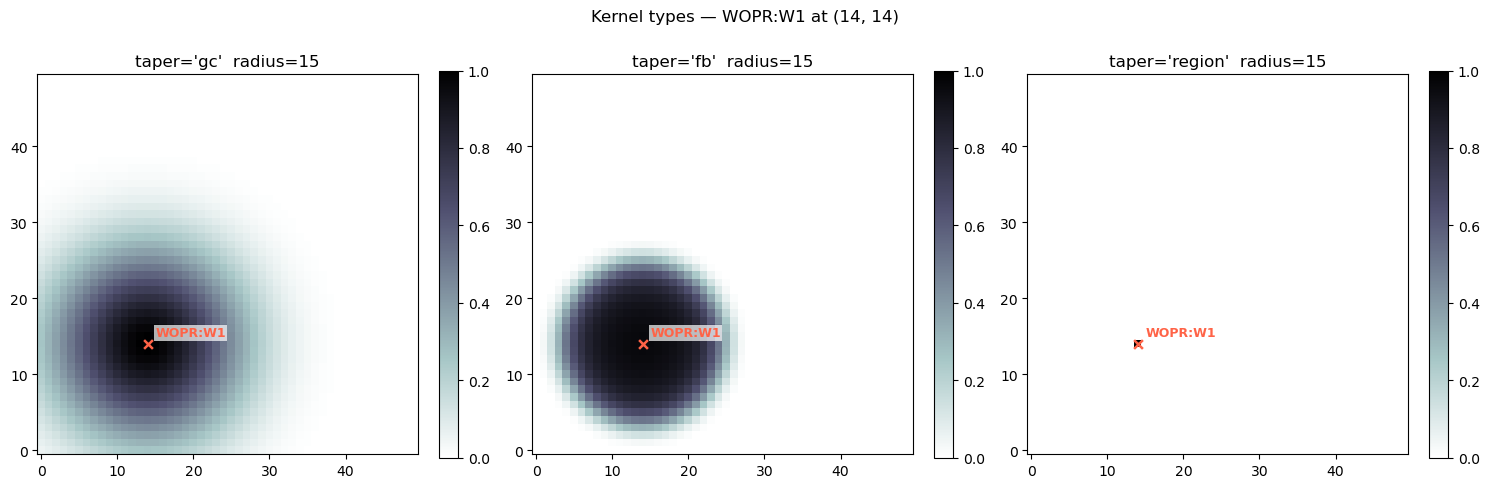

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, taper_tag in zip(axes, ["gc", "fb", "region"]):
    loc = DistanceLocalization(
        info={
            "name":  "distance_loc",
            "field": [1, 50, 50],
            "entries": [
                {"taper": taper_tag, "x": well1_x, "y": well1_y, "radius": 15,
                 "data_type": well1_name, "time": "2005-01-01", "param": "PORO"},
            ],
        },
        data=data,
        parameters=["PORO"],
        prior_info={"PORO": {"nx": 50, "ny": 50, "nz": 1}},
    )
    T = loc(curr_data=[well1_name], curr_time=[pd.Timestamp("2005-01-01")])
    mask = T.toarray()[:, 0].reshape(50, 50, order="F")
    im = ax.imshow(mask, cmap="bone_r", origin="lower", vmin=0, vmax=1)
    ax.scatter([well1_x], [well1_y], c="tomato", s=40, marker="x", linewidths=1.8)
    ax.text(
        well1_x + 1, well1_y + 1, well1_name,
        color="tomato", fontsize=9, weight="bold",
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 1},
    )
    ax.set_title(f"taper='{taper_tag}'  radius=15")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f"Kernel types — {well1_name} at ({well1_x}, {well1_y})")
plt.tight_layout()
plt.show()

## 3. Effect of `radius`

`radius` is the kernel half-radius in grid cells. Gaspari-Cohn support extends to `2 × radius`.

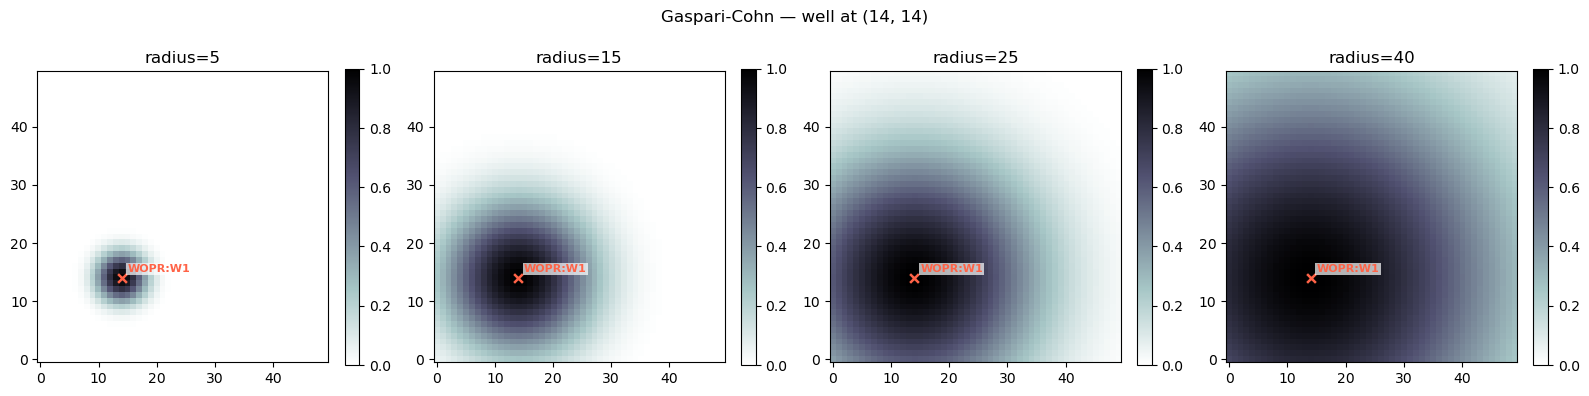

In [4]:
radii = [5, 15, 25, 40]
fig, axes = plt.subplots(1, len(radii), figsize=(16, 4))

for ax, r in zip(axes, radii):
    loc = DistanceLocalization(
        info={
            "name":  "distance_loc",
            "field": [1, 50, 50],
            "entries": [{"taper": "gc", "x": well1_x, "y": well1_y, "radius": r}],
        },
        data=data,
        parameters=["PORO"],
        prior_info={"PORO": {"nx": 50, "ny": 50, "nz": 1}},
    )
    T = loc(curr_data=[well1_name], curr_time=[pd.Timestamp("2005-01-01")])
    mask = T.toarray()[:, 0].reshape(50, 50, order="F")
    im = ax.imshow(mask, cmap="bone_r", origin="lower", vmin=0, vmax=1)
    ax.scatter([well1_x], [well1_y], c="tomato", s=40, marker="x", linewidths=1.8)
    ax.text(
        well1_x + 1, well1_y + 1, well1_name,
        color="tomato", fontsize=8, weight="bold",
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 1},
    )
    ax.set_title(f"radius={r}")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f"Gaspari-Cohn — well at ({well1_x}, {well1_y})")
plt.tight_layout()
plt.show()

## 4. Two synthetic wells — per-observation entries

Each entry targets one `data_type`. Here we use two synthetic wells, `WOPR:W1` and `WOPR:W2`, with different kernels and radii.
Omitting `time` and `param` applies the entry to all times and parameters.

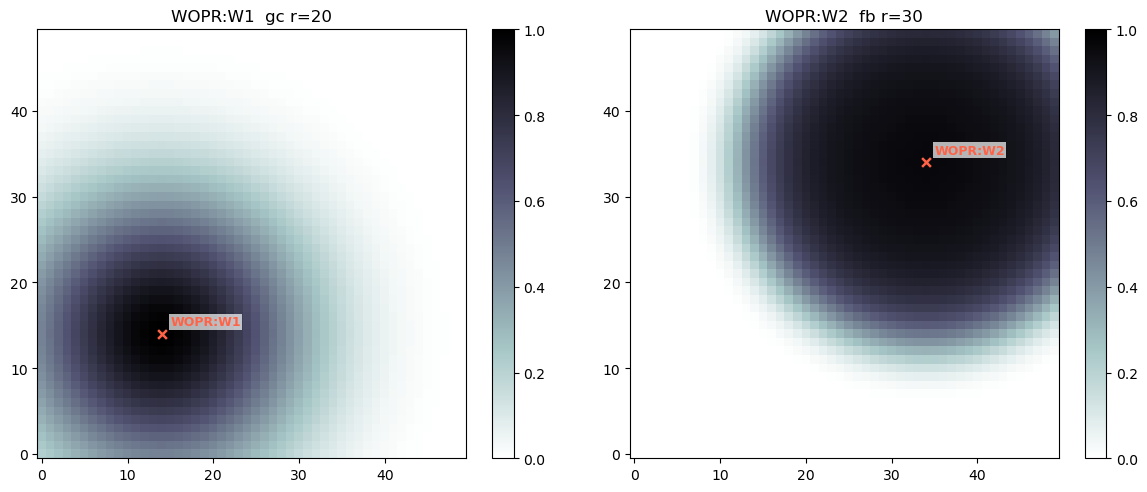

In [5]:
loc = DistanceLocalization(
    info={
        "name":  "distance_loc",
        "field": [1, 50, 50],
        "entries": [
            {"taper": "gc", "x": well1_x, "y": well1_y, "radius": 20, "data_type": well1_name},
            {"taper": "fb", "x": well2_x, "y": well2_y, "radius": 30, "data_type": well2_name},
        ],
    },
    data=data,
    parameters=["PORO"],
    prior_info={"PORO": {"nx": 50, "ny": 50, "nz": 1}},
)

T = loc(curr_data=[well1_name, well2_name], curr_time=[pd.Timestamp("2005-01-01")])
T = T.toarray()

obs_xy = [(well1_x, well1_y), (well2_x, well2_y)]
obs_names = [well1_name, well2_name]
titles = [
    f"{well1_name}  gc r=20",
    f"{well2_name}  fb r=30",
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title, (ox, oy), obs_name in zip(axes, [0, 1], titles, obs_xy, obs_names):
    im = ax.imshow(T[:, col].reshape(50, 50, order="F"),
                   cmap="bone_r", origin="lower", vmin=0, vmax=1)
    ax.scatter([ox], [oy], c="tomato", s=40, marker="x", linewidths=1.8)
    ax.text(
        ox + 1, oy + 1, obs_name,
        color="tomato", fontsize=9, weight="bold",
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 1},
    )
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

## 5. 3D case (layered reservoir)

Yes, distance-based localization also works in 3D.
This example uses a 6-layer grid and places one observation in the middle layer. We visualize several horizontal slices and one vertical profile through the well to show decay in both lateral and vertical directions.

(9600, 1)


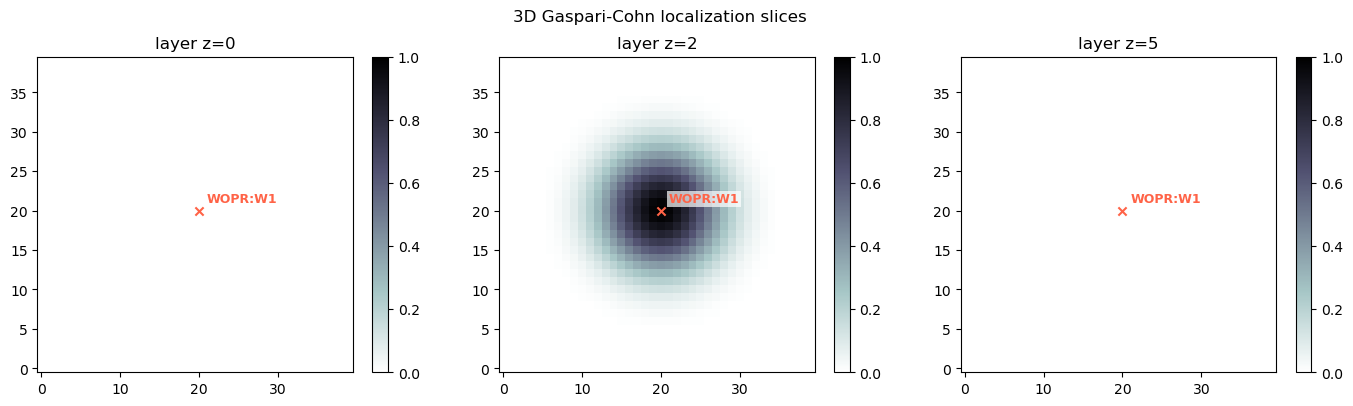

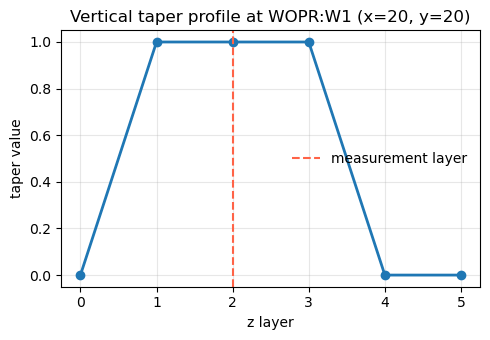

In [6]:
# 3D example: one synthetic observation localized in a layered grid
nz, nx, ny = 6, 40, 40
well_x, well_y, well_z = 20, 20, 2

loc3d = DistanceLocalization(
    info={
        "name": "distance_loc",
        "field": [nz, nx, ny],
        "entries": [
            {
                "taper": "gc",
                "x": well_x, "y": well_y, "z": well_z,
                "radius": 9,
                "z_range": 1,
                "data_type": well1_name,
                "time": "2005-01-01",
                "param": "PORO",
            },
        ],
    },
    data=data,
    parameters=["PORO"],
    prior_info={"PORO": {"nx": nx, "ny": ny, "nz": nz}},
)

T3 = loc3d(curr_data=[well1_name], curr_time=[pd.Timestamp("2005-01-01")]).toarray()
print(T3.shape)
mask3d = T3[:, 0].reshape(nx, ny, nz, order="F")

# Show horizontal slices across layers
slice_layers = [0, 2, 5]
fig, axes = plt.subplots(1, len(slice_layers), figsize=(14, 4))
for ax, k in zip(axes, slice_layers):
    im = ax.imshow(mask3d[:, :, k].T, cmap="bone_r", origin="lower", vmin=0, vmax=1)
    ax.set_title(f"layer z={k}")
    ax.scatter([well_x], [well_y], c="tomato", s=35, marker="x")
    ax.text(
        well_x + 1, well_y + 1, well1_name,
        color="tomato", fontsize=9, weight="bold",
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 1},
    )
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("3D Gaspari-Cohn localization slices")
plt.tight_layout()
plt.show()

# Vertical profile through the well location
vertical = mask3d[well_x, well_y, :]
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(nz), vertical, marker="o", lw=2)
plt.axvline(well_z, color="tomato", ls="--", lw=1.5, label="measurement layer")
plt.xlabel("z layer")
plt.ylabel("taper value")
plt.ylim(-0.05, 1.05)
plt.title(f"Vertical taper profile at {well1_name} (x={well_x}, y={well_y})")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. CSV file and TOML / YAML configuration

**`loc_entries.csv`** — one row per entry, space-separated:
```
# taper  x   y   z  radius  z_range  aniso  rotation  data_type  time        param
gc       14  14  0  20      :        1.0    0.0       WOPR:W1    2005-01-01  PORO
fb       34  34  0  30      :        1.0    0.0       WOPR:W2    2005-01-01  PORO
```
Use `*` in `data_type`, `time`, or `param` to match all values.

---

**TOML** — reference the CSV or use inline entries:
```toml
[dataassim.localization]
name    = "distance_loc"
field   = [1, 50, 50]     # [nz, nx, ny]
entries = "loc_entries.csv"
```
Or inline:
```toml
[dataassim.localization]
name  = "distance_loc"
field = [1, 50, 50]
entries = [
    {taper="gc", x=14, y=14, radius=20, data_type="WOPR:W1"},
    {taper="fb", x=34, y=34, radius=30, data_type="WOPR:W2"},
]
```

---

**YAML** — equivalent configuration:
```yaml
dataassim:
  localization:
    name:    distance_loc
    field:   [1, 50, 50]
    entries: loc_entries.csv
```
Or inline:
```yaml
dataassim:
  localization:
    name:  distance_loc
    field: [1, 50, 50]
    entries:
      - {taper: gc, x: 14, y: 14, radius: 20, data_type: "WOPR:W1"}
      - {taper: fb, x: 34, y: 34, radius: 30, data_type: "WOPR:W2"}
```

Optional entry fields: `z=0`, `z_range=":"`, `aniso=1.0`, `rotation=0.0`, `time="*"`, `param="*"`